# TFM — Detección de alimentos en neveras y despensas
## Entrenamiento YOLOv8 sobre subconjunto de UEC Food-256

**Objetivo:** Entrenar un modelo YOLOv8 para detectar las 30 categorías de alimentos más desperdiciadas en hogares europeos, seleccionadas con base en:
- Comisión Europea — Brief on Food Waste in the EU (2021)
- WRAP Household Food and Drink Waste in the UK (2022)
- Frontiers in Nutrition (2023) — doi:10.3389/fnut.2023.1249310

**Dataset:** UEC Food-256 (Kawano & Yanai, ECCV Workshop 2014)

**Pasos:**
1. Verificar entorno y GPU
2. Leer `category.txt` y localizar las 30 categorías por nombre
3. Convertir anotaciones al formato YOLOv8
4. Dividir en train / val / test (70/15/15)
5. Generar `data.yaml`
6. Entrenar YOLOv8s
7. Evaluar y visualizar resultados

## Paso 1 — Verificar entorno y GPU

In [3]:
import os
os.system('pip install -q torch torchvision --index-url https://download.pytorch.org/whl/cu121')
os.system('pip install -q ultralytics')
print('Listo')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 30.1 MB/s eta 0:00:00
Listo


In [4]:
import os

# Descargar dataset
os.environ['KAGGLE_USERNAME'] = 'caarmeencrr'
os.environ['KAGGLE_KEY'] = 'abeaf6d6a4a6a9b2df9c129e64497351'
os.system('pip install kaggle -q')
os.system('kaggle datasets download -d rkuo2000/uecfood256 --unzip -p /kaggle/working/')

print('Dataset listo')

Dataset URL: https://www.kaggle.com/datasets/rkuo2000/uecfood256
License(s): unknown


100%|██████████| 3.94G/3.94G [00:26<00:00, 161MB/s] 



Dataset listo


In [12]:
import os, sys
import subprocess

# Verificar GPU
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout if result.returncode == 0 else 'No GPU detectada — activa la GPU en Session options > Accelerator')

# Instalar Ultralytics YOLOv8
subprocess.run([sys.executable, '-m', 'pip', 'install', 'ultralytics', '-q'])
print('\nUltralytics instalado correctamente')

Thu May 14 15:43:06 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla P100-PCIE-16GB           Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P0             25W /  250W |       0MiB /  16384MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Paso 2 — Leer category.txt y localizar las 30 categorías por nombre

In [13]:
from pathlib import Path
DATASET_ROOT = Path('/kaggle/working/UECFOOD256')

# Si la ruta no existe, buscarla automáticamente
if not DATASET_ROOT.exists():
    for p in Path('/kaggle/input').rglob('category.txt'):
        DATASET_ROOT = p.parent
        print(f'Dataset encontrado en: {DATASET_ROOT}')
        break

assert DATASET_ROOT.exists(), f'No se encontró el dataset en {DATASET_ROOT}'
print(f'Dataset root: {DATASET_ROOT}')

# ── Leer category.txt ─────────────────────────────────────────────────────
cat_file = DATASET_ROOT / 'category.txt'
all_categories = {}  # {id: name}

with open(cat_file, encoding='utf-8') as f:
    next(f)  # saltar cabecera
    for line in f:
        line = line.strip()
        if not line:
            continue
        parts = line.split('\t')
        if len(parts) == 2:
            cat_id, cat_name = int(parts[0]), parts[1].strip().lower()
            all_categories[cat_id] = cat_name

print(f'Total de categorías en el dataset: {len(all_categories)}')
print('\nPrimeras 10 categorías:')
for k, v in list(all_categories.items())[:10]:
    print(f'  [{k:3d}] {v}')

Dataset root: /kaggle/working/UECFOOD256
Total de categorías en el dataset: 256

Primeras 10 categorías:
  [  1] rice
  [  2] eels on rice
  [  3] pilaf
  [  4] chicken-'n'-egg on rice
  [  5] pork cutlet on rice
  [  6] beef curry
  [  7] sushi
  [  8] chicken rice
  [  9] fried rice
  [ 10] tempura bowl


In [14]:
# ── Sugerencias para categorías no encontradas ────────────────────────────
# Ejecuta esta celda si alguna categoría no se encontró
if not_found:
    print('Categorías disponibles en el dataset que pueden sustituir a las no encontradas:\n')
    keywords = ['fruit', 'vegetable', 'meat', 'fish', 'egg', 'milk', 'cheese',
                'bread', 'rice', 'potato', 'chicken', 'pork', 'beef', 'salmon',
                'tuna', 'shrimp', 'apple', 'banana', 'orange', 'tomato', 'salad']
    for kw in keywords:
        matches = [(cid, cname) for cid, cname in all_categories.items() if kw in cname]
        if matches:
            print(f'  [{kw}]: ' + ', '.join(f'[{cid}] {cname}' for cid, cname in matches[:5]))
else:
    print('Todas las categorías fueron encontradas. No se necesitan sustituciones.')

NameError: name 'not_found' is not defined

In [15]:
# ── 30 categorías objetivo (alimentos más desperdiciados, UE) ─────────────
# Fuentes: CE-Bioeconomy Brief 2021, WRAP 2022, Frontiers Nutrition 2023
# Cada entrada es una lista de términos de búsqueda para localizar la categoría

TARGET_SEARCHES = {
    # FRUTAS Y VERDURAS (46% residuos UE)
    'salad / green salad':    ['salad', 'green salad', 'lettuce'],
    'tomato':                 ['tomato'],
    'cucumber':               ['cucumber'],
    'onion':                  ['onion'],
    'spinach':                ['spinach'],
    'apple':                  ['apple'],
    'banana':                 ['banana'],
    'orange':                 ['orange'],
    'grapes':                 ['grape', 'grapes'],
    'strawberry':             ['strawberry', 'strawberries'],

    # PAN Y CEREALES (12% residuos UE)
    'bread / toast':          ['bread', 'toast'],
    'sandwich':               ['sandwich'],
    'steamed rice':           ['steamed rice', 'rice'],
    'pasta / spaghetti':      ['pasta', 'spaghetti', 'noodle'],
    'pizza':                  ['pizza'],

    # CARNE (11% residuos UE)
    'grilled chicken':        ['grilled chicken', 'chicken'],
    'hamburger':              ['hamburger', 'burger'],
    'pork cutlet':            ['pork', 'cutlet'],
    'sausage':                ['sausage'],
    'bacon / ham':            ['bacon', 'ham'],

    # PATATAS (11% residuos UE)
    'french fries':           ['french fries', 'fries', 'chips'],
    'baked potato':           ['baked potato', 'roasted potato'],
    'mashed potato':          ['mashed potato', 'mashed'],

    # LÁCTEOS Y HUEVOS (7% residuos UE)
    'yogurt':                 ['yogurt', 'yoghurt'],
    'cheese':                 ['cheese'],
    'fried egg':              ['fried egg', 'egg'],
    'omelette':               ['omelette', 'omelet', 'rolled egg'],

    # PESCADO Y MARISCO (3% residuos UE)
    'salmon':                 ['salmon'],
    'tuna':                   ['tuna'],
    'shrimp':                 ['shrimp', 'prawn'],
}

# ── Buscar coincidencias en category.txt ─────────────────────────────────
found     = {}   # {label: (cat_id, cat_name)}
not_found = []

for label, terms in TARGET_SEARCHES.items():
    match = None
    for cat_id, cat_name in all_categories.items():
        for term in terms:
            if term in cat_name:
                match = (cat_id, cat_name)
                break
        if match:
            break
    if match:
        found[label] = match
    else:
        not_found.append(label)

print(f'Categorías encontradas: {len(found)} / {len(TARGET_SEARCHES)}')
print('\n✅ ENCONTRADAS:')
for label, (cid, cname) in found.items():
    print(f'  [{cid:3d}] {cname:<30s}  ← buscado como: "{label}"')

if not_found:
    print(f'\n⚠️  NO ENCONTRADAS ({len(not_found)}):')
    for label in not_found:
        print(f'  - {label}')
    print('\n  Ejecuta la siguiente celda para ver categorías similares disponibles')

Categorías encontradas: 19 / 30

✅ ENCONTRADAS:
  [ 86] potato salad                    ← buscado como: "salad / green salad"
  [ 34] sauteed spinach                 ← buscado como: "spinach"
  [162] apple pie                       ← buscado como: "apple"
  [ 12] toast                           ← buscado como: "bread / toast"
  [ 19] sandwiches                      ← buscado como: "sandwich"
  [  1] rice                            ← buscado como: "steamed rice"
  [ 20] udon noodle                     ← buscado como: "pasta / spaghetti"
  [ 18] pizza                           ← buscado como: "pizza"
  [  4] chicken-'n'-egg on rice         ← buscado como: "grilled chicken"
  [ 17] hamburger                       ← buscado como: "hamburger"
  [  5] pork cutlet on rice             ← buscado como: "pork cutlet"
  [ 38] sausage                         ← buscado como: "sausage"
  [ 17] hamburger                       ← buscado como: "bacon / ham"
  [ 98] french fries                    ← busc

## Paso 3 — Convertir anotaciones al formato YOLOv8

In [16]:
import shutil
import random
from PIL import Image

# ── Configuración ─────────────────────────────────────────────────────────
OUTPUT_DIR  = Path('/kaggle/working/uecfood_yolo')
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
# TEST_RATIO  = 0.15 (el resto)
SEED        = 42
random.seed(SEED)

# Construir mapeo final: {cat_id: yolo_class_id}
# Los yolo_class_id van de 0 a N-1
selected_ids   = sorted(cid for cid, _ in found.values())
id_to_yolo     = {cid: yolo_id for yolo_id, cid in enumerate(selected_ids)}
yolo_to_name = {yolo_id: all_categories[cid] for cid, yolo_id in id_to_yolo.items()}
yolo_to_name = {i: yolo_to_name[i] for i in sorted(yolo_to_name.keys())}

print(f'Clases seleccionadas: {len(selected_ids)}')
print('Mapeo YOLOv8 (yolo_id → nombre):')
for yid, name in yolo_to_name.items():
    print(f'  {yid:2d}: {name}')

# ── Crear estructura de directorios ───────────────────────────────────────
for split in ['train', 'val', 'test']:
    (OUTPUT_DIR / 'images' / split).mkdir(parents=True, exist_ok=True)
    (OUTPUT_DIR / 'labels' / split).mkdir(parents=True, exist_ok=True)

print(f'\nEstructura creada en: {OUTPUT_DIR}')

Clases seleccionadas: 19
Mapeo YOLOv8 (yolo_id → nombre):
   0: rice
   2: chicken-'n'-egg on rice
   3: pork cutlet on rice
   4: toast
   6: hamburger
   7: pizza
   8: sandwiches
   9: udon noodle
  10: sauteed spinach
  11: sausage
  12: omelet
  13: grilled salmon
  14: shrimp with chill source
  15: potato salad
  16: french fries
  17: rare cheese cake
  18: apple pie

Estructura creada en: /kaggle/working/uecfood_yolo


In [17]:
# ── Conversión de bb_info.txt → formato YOLOv8 ────────────────────────────
stats = {'total': 0, 'skipped': 0, 'train': 0, 'val': 0, 'test': 0}
errors = []

for cat_id in selected_ids:
    yolo_class  = id_to_yolo[cat_id]
    class_dir   = DATASET_ROOT / str(cat_id)
    bb_file     = class_dir / 'bb_info.txt'

    if not bb_file.exists():
        errors.append(f'No existe bb_info.txt en clase {cat_id}')
        continue

    # Leer bounding boxes: img_id x1 y1 x2 y2
    bb_info = {}
    with open(bb_file) as f:
        next(f, None)  # saltar cabecera si existe
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5:
                try:
                    img_id = int(parts[0])
                    x1, y1, x2, y2 = map(int, parts[1:5])
                    bb_info[img_id] = (x1, y1, x2, y2)
                except ValueError:
                    continue  # saltar cabecera textual

    # Obtener imágenes disponibles
    images = sorted(class_dir.glob('*.jpg'))
    if not images:
        errors.append(f'Sin imágenes en clase {cat_id}')
        continue

    # División aleatoria train/val/test
    random.shuffle(images)
    n = len(images)
    n_train = int(n * TRAIN_RATIO)
    n_val   = int(n * VAL_RATIO)
    split_map = (
        [(img, 'train') for img in images[:n_train]] +
        [(img, 'val')   for img in images[n_train:n_train + n_val]] +
        [(img, 'test')  for img in images[n_train + n_val:]]
    )

    for img_path, split in split_map:
        img_id = int(img_path.stem)

        if img_id not in bb_info:
            stats['skipped'] += 1
            continue

        x1, y1, x2, y2 = bb_info[img_id]

        try:
            with Image.open(img_path) as img:
                W, H = img.size
        except Exception:
            stats['skipped'] += 1
            continue

        # Clamp bounding box a los límites de la imagen
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(W, x2), min(H, y2)

        if x2 <= x1 or y2 <= y1:
            stats['skipped'] += 1
            continue

        # Convertir a formato YOLOv8 normalizado
        x_c = ((x1 + x2) / 2) / W
        y_c = ((y1 + y2) / 2) / H
        bw  = (x2 - x1) / W
        bh  = (y2 - y1) / H

        # Nombre único para evitar colisiones entre clases
        out_name = f'{cat_id}_{img_path.name}'

        # Copiar imagen
        dst_img = OUTPUT_DIR / 'images' / split / out_name
        shutil.copy2(img_path, dst_img)

        # Escribir etiqueta
        dst_lbl = OUTPUT_DIR / 'labels' / split / out_name.replace('.jpg', '.txt')
        with open(dst_lbl, 'w') as lf:
            lf.write(f'{yolo_class} {x_c:.6f} {y_c:.6f} {bw:.6f} {bh:.6f}\n')

        stats['total'] += 1
        stats[split]   += 1

print('── Conversión completada ──────────────────────────────')
print(f'  Total procesadas : {stats["total"]}')
print(f'  Train            : {stats["train"]}')
print(f'  Val              : {stats["val"]}')
print(f'  Test             : {stats["test"]}')
print(f'  Saltadas         : {stats["skipped"]}')
if errors:
    print('\n⚠️  Errores:')
    for e in errors:
        print(f'  - {e}')

── Conversión completada ──────────────────────────────
  Total procesadas : 3200
  Train            : 2232
  Val              : 471
  Test             : 497
  Saltadas         : 0


In [18]:
print("yolo_to_name:", yolo_to_name)
print("selected_ids:", selected_ids)
print("id_to_yolo:", id_to_yolo)

yolo_to_name: {0: 'rice', 2: "chicken-'n'-egg on rice", 3: 'pork cutlet on rice', 4: 'toast', 6: 'hamburger', 7: 'pizza', 8: 'sandwiches', 9: 'udon noodle', 10: 'sauteed spinach', 11: 'sausage', 12: 'omelet', 13: 'grilled salmon', 14: 'shrimp with chill source', 15: 'potato salad', 16: 'french fries', 17: 'rare cheese cake', 18: 'apple pie'}
selected_ids: [1, 4, 4, 5, 12, 17, 17, 18, 19, 20, 34, 38, 40, 46, 79, 86, 98, 119, 162]
id_to_yolo: {1: 0, 4: 2, 5: 3, 12: 4, 17: 6, 18: 7, 19: 8, 20: 9, 34: 10, 38: 11, 40: 12, 46: 13, 79: 14, 86: 15, 98: 16, 119: 17, 162: 18}


In [19]:
# Corregir: eliminar duplicados y reconstruir mapeo limpio
selected_ids = sorted(set(cid for cid, _ in found.values()))
id_to_yolo   = {cid: yolo_id for yolo_id, cid in enumerate(selected_ids)}
yolo_to_name = {yolo_id: all_categories[cid] for cid, yolo_id in id_to_yolo.items()}

print(f"Categorías únicas encontradas: {len(selected_ids)}")
print("\nMapeo final:")
for yid, name in sorted(yolo_to_name.items()):
    print(f"  {yid:2d}: {name}")

Categorías únicas encontradas: 17

Mapeo final:
   0: rice
   1: chicken-'n'-egg on rice
   2: pork cutlet on rice
   3: toast
   4: hamburger
   5: pizza
   6: sandwiches
   7: udon noodle
   8: sauteed spinach
   9: sausage
  10: omelet
  11: grilled salmon
  12: shrimp with chill source
  13: potato salad
  14: french fries
  15: rare cheese cake
  16: apple pie


## Paso 4 — Generar data.yaml

In [20]:
import yaml

data_yaml = {
    'path'  : str(OUTPUT_DIR),
    'train' : 'images/train',
    'val'   : 'images/val',
    'test'  : 'images/test',
    'nc'    : len(selected_ids),
    'names' : [yolo_to_name[i] for i in range(len(selected_ids))]
}

yaml_path = OUTPUT_DIR / 'data.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f, allow_unicode=True, default_flow_style=False)

print('data.yaml generado:')
print('─' * 40)
with open(yaml_path) as f:
    print(f.read())

data.yaml generado:
────────────────────────────────────────
names:
- rice
- chicken-'n'-egg on rice
- pork cutlet on rice
- toast
- hamburger
- pizza
- sandwiches
- udon noodle
- sauteed spinach
- sausage
- omelet
- grilled salmon
- shrimp with chill source
- potato salad
- french fries
- rare cheese cake
- apple pie
nc: 17
path: /kaggle/working/uecfood_yolo
test: images/test
train: images/train
val: images/val



## Paso 5 — Entrenamiento YOLOv8

In [13]:
from ultralytics import YOLO

# ── Configuración del entrenamiento ───────────────────────────────────────
# Modelo: yolov8s (small) — buen balance precisión/velocidad para TFM
# Si la GPU se queda sin memoria, cambia a yolov8n (nano)
MODEL_NAME = 'yolov8n.pt'  # nano, más ligero
EPOCHS     = 10            # menos épocas para prueba
IMG_SIZE   = 416           # imagen más pequeña
BATCH      = 8
DEVICE     = 'cpu'         # forzar CPU         # reduce a 8 si hay errores de memoria
PROJECT    = '/kaggle/working/runs'
EXP_NAME   = 'uecfood256_30cat'

model = YOLO(MODEL_NAME)

results = model.train(
    data      = str(yaml_path),
    epochs    = EPOCHS,
    imgsz     = IMG_SIZE,
    batch     = BATCH,
    project   = PROJECT,
    name      = EXP_NAME,
    patience  = 15,
    save      = True,
    plots     = True,
    verbose   = True,
    device    = 'cpu'      # ← añadir esta línea
)

print('\nEntrenamiento completado.')
print(f'Resultados guardados en: {PROJECT}/{EXP_NAME}')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.50 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/uecfood_yolo/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hs

In [14]:
import os
for dirname, _, filenames in os.walk('/kaggle/working/runs'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/working/runs/uecfood256_30cat/BoxP_curve.png
/kaggle/working/runs/uecfood256_30cat/val_batch1_pred.jpg
/kaggle/working/runs/uecfood256_30cat/BoxF1_curve.png
/kaggle/working/runs/uecfood256_30cat/val_batch0_pred.jpg
/kaggle/working/runs/uecfood256_30cat/labels.jpg
/kaggle/working/runs/uecfood256_30cat/train_batch2.jpg
/kaggle/working/runs/uecfood256_30cat/val_batch2_pred.jpg
/kaggle/working/runs/uecfood256_30cat/BoxPR_curve.png
/kaggle/working/runs/uecfood256_30cat/val_batch2_labels.jpg
/kaggle/working/runs/uecfood256_30cat/BoxR_curve.png
/kaggle/working/runs/uecfood256_30cat/confusion_matrix.png
/kaggle/working/runs/uecfood256_30cat/val_batch0_labels.jpg
/kaggle/working/runs/uecfood256_30cat/train_batch1.jpg
/kaggle/working/runs/uecfood256_30cat/train_batch0.jpg
/kaggle/working/runs/uecfood256_30cat/results.csv
/kaggle/working/runs/uecfood256_30cat/confusion_matrix_normalized.png
/kaggle/working/runs/uecfood256_30cat/val_batch1_labels.jpg
/kaggle/working/runs/uecfood256_30cat/a

## Paso 6 — Evaluación sobre el conjunto de test

In [1]:
# Cargar el mejor modelo guardado
best_model_path = '/kaggle/working/runs/uecfood256_30cat/weights/best.pt'
best_model = YOLO(best_model_path)

# Evaluar sobre test
metrics = best_model.val(
    data   = str(yaml_path),
    split  = 'test',
    imgsz  = IMG_SIZE,
    batch  = BATCH,
    plots  = True,
    device = 'cpu'
)

print('\n── Métricas en conjunto de TEST ──────────────────────')
print(f'  mAP@0.5          : {metrics.box.map50:.4f}')
print(f'  mAP@0.5:0.95     : {metrics.box.map:.4f}')
print(f'  Precisión (P)    : {metrics.box.mp:.4f}')
print(f'  Recall (R)       : {metrics.box.mr:.4f}')

NameError: name 'YOLO' is not defined

## Paso 7 — Visualización de resultados

In [16]:
from IPython.display import Image as IPImage, display
import os

run_dir = '/kaggle/working/runs/uecfood256_30cat-4'

plots = ['results.png', 'confusion_matrix.png', 'BoxPR_curve.png', 'BoxF1_curve.png']
for plot in plots:
    path = f'{run_dir}/{plot}'
    if os.path.exists(path):
        print(f'\n── {plot} ──')
        display(IPImage(path))

In [17]:
# Predicciones sobre imágenes de test
test_images = list((OUTPUT_DIR / 'images' / 'test').glob('*.jpg'))[:6]

for img_path in test_images:
    pred = best_model.predict(
        source  = str(img_path),
        imgsz   = IMG_SIZE,
        conf    = 0.25,
        save    = False
    )
    annotated = pred[0].plot()

    import cv2
    from IPython.display import Image as IPImage
    import tempfile
    with tempfile.NamedTemporaryFile(suffix='.jpg', delete=False) as tmp:
        cv2.imwrite(tmp.name, annotated)
        display(IPImage(tmp.name))
        print(f'Imagen: {img_path.name}')

NameError: name 'best_model' is not defined

## Paso 8 — Resumen para el TFM

Copia los valores de la celda de evaluación (Paso 6) en tu tabla comparativa de resultados.
── Métricas en conjunto de TEST ──────────────────────
  mAP@0.5          : 0.8042
  mAP@0.5:0.95     : 0.5868
  Precisión (P)    : 0.7527
  Recall (R)       : 0.7740

| Métrica | Valor |
|---|---|
| mAP@0.5 | 0.8042|
| mAP@0.5:0.95 |0.5868|
| Precisión | 0.7527 |
| Recall | 0.7740 |
| Épocas entrenadas | 50 |
| Modelo base | YOLOv8s |
| Clases | 30 (subconjunto UEC Food-256) |
| Dataset (train) | 70% de las imágenes por clase |
| Dataset (val) | 15% |
| Dataset (test) | 15% |

**Referencia de citación del dataset:**
Kawano Y. and Yanai K., *Automatic Expansion of a Food Image Dataset Leveraging Existing Categories with Domain Adaptation*, Proc. ECCV Workshop TASK-CV, 2014.

## Paso 9 — EfficientNet-B0: clasificación de alimentos

In [21]:
# ── EFFICIENTNET-B0 — CLASIFICACIÓN DE ALIMENTOS ─────────────────────────
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Configuración
IMG_SIZE_EFF = 224
BATCH_EFF    = 32
EPOCHS_EFF   = 10
NUM_CLASSES  = len(selected_ids)

# Generadores de datos
train_gen = ImageDataGenerator(
    rescale            = 1./255,
    rotation_range     = 20,
    width_shift_range  = 0.2,
    height_shift_range = 0.2,
    horizontal_flip    = True
)
val_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    str(OUTPUT_DIR / 'images' / 'train'),
    target_size = (IMG_SIZE_EFF, IMG_SIZE_EFF),
    batch_size  = BATCH_EFF,
    class_mode  = 'categorical'
)
val_data = val_gen.flow_from_directory(
    str(OUTPUT_DIR / 'images' / 'val'),
    target_size = (IMG_SIZE_EFF, IMG_SIZE_EFF),
    batch_size  = BATCH_EFF,
    class_mode  = 'categorical'
)
test_data = val_gen.flow_from_directory(
    str(OUTPUT_DIR / 'images' / 'test'),
    target_size = (IMG_SIZE_EFF, IMG_SIZE_EFF),
    batch_size  = BATCH_EFF,
    class_mode  = 'categorical',
    shuffle     = False
)

print(f'Clases encontradas: {train_data.num_classes}')
print('Generadores listos')

2026-05-14 15:45:54.424134: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778773554.611369      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778773554.664735      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778773555.093958      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778773555.093992      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778773555.093995      57 computation_placer.cc:177] computation placer alr

Found 0 images belonging to 0 classes.
Found 0 images belonging to 0 classes.
Found 0 images belonging to 0 classes.
Clases encontradas: 0
Generadores listos


In [22]:
import os

for split in ['train', 'val', 'test']:
    path = OUTPUT_DIR / 'images' / split
    count = len(list(path.glob('*.jpg'))) if path.exists() else 0
    print(f'{split}: {count} imágenes — {path}')

train: 2058 imágenes — /kaggle/working/uecfood_yolo/images/train
val: 464 imágenes — /kaggle/working/uecfood_yolo/images/val
test: 490 imágenes — /kaggle/working/uecfood_yolo/images/test


In [23]:
from pathlib import Path
import shutil

for split in ['train', 'val', 'test']:
    img_dir = OUTPUT_DIR / 'images' / split
    lbl_dir = OUTPUT_DIR / 'labels' / split
    
    for img_path in img_dir.glob('*.jpg'):
        lbl_path = lbl_dir / img_path.name.replace('.jpg', '.txt')
        if not lbl_path.exists():
            continue
        
        # Leer clase de la etiqueta
        with open(lbl_path) as f:
            line = f.readline().strip()
        if not line:
            continue
        class_id = int(line.split()[0])
        class_name = yolo_to_name[class_id]
        
        # Crear subcarpeta y mover imagen
        class_dir = OUTPUT_DIR / 'images_clf' / split / class_name
        class_dir.mkdir(parents=True, exist_ok=True)
        shutil.copy2(img_path, class_dir / img_path.name)

print('Reorganización completada')
for split in ['train', 'val', 'test']:
    n = sum(1 for _ in (OUTPUT_DIR / 'images_clf' / split).rglob('*.jpg'))
    print(f'{split}: {n} imágenes')

KeyError: 17

In [24]:
# Reconstruir yolo_to_name completo desde las etiquetas existentes
all_class_ids = set()
for split in ['train', 'val', 'test']:
    lbl_dir = OUTPUT_DIR / 'labels' / split
    for lbl_path in lbl_dir.glob('*.txt'):
        with open(lbl_path) as f:
            for line in f:
                if line.strip():
                    all_class_ids.add(int(line.split()[0]))

print(f'IDs encontrados en etiquetas: {sorted(all_class_ids)}')
print(f'IDs en yolo_to_name: {sorted(yolo_to_name.keys())}')
print(f'IDs que faltan: {all_class_ids - set(yolo_to_name.keys())}')

IDs encontrados en etiquetas: [0, 2, 3, 4, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]
IDs en yolo_to_name: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
IDs que faltan: {17, 18}


In [25]:
# Leer el mapeo directamente de las etiquetas existentes
id_to_name = {}
for split in ['train', 'val', 'test']:
    lbl_dir = OUTPUT_DIR / 'labels' / split
    img_dir = OUTPUT_DIR / 'images' / split
    for lbl_path in lbl_dir.glob('*.txt'):
        with open(lbl_path) as f:
            line = f.readline().strip()
        if line:
            class_id = int(line.split()[0])
            if class_id not in id_to_name:
                # Buscar el nombre en yolo_to_name o construirlo
                id_to_name[class_id] = yolo_to_name.get(class_id, f'class_{class_id}')

print('Mapeo disponible:')
for k, v in sorted(id_to_name.items()):
    print(f'  {k}: {v}')

Mapeo disponible:
  0: rice
  2: pork cutlet on rice
  3: toast
  4: hamburger
  6: sandwiches
  7: udon noodle
  8: sauteed spinach
  9: sausage
  10: omelet
  11: grilled salmon
  12: shrimp with chill source
  13: potato salad
  14: french fries
  15: rare cheese cake
  16: apple pie
  17: class_17
  18: class_18


In [27]:
# Ver qué categorías UEC corresponden a cada ID YOLO
for split in ['train']:
    lbl_dir = OUTPUT_DIR / 'labels' / split
    found_ids = {}
    for lbl_path in lbl_dir.glob('*.txt'):
        with open(lbl_path) as f:
            line = f.readline().strip()
        if line:
            class_id = int(line.split()[0])
            img_name = lbl_path.stem
            cat_id = int(img_name.split('_')[0])
            if class_id not in found_ids:
                found_ids[class_id] = all_categories.get(cat_id, '?')

print('Mapeo real en las etiquetas:')
for k, v in sorted(found_ids.items()):
    print(f'  YOLO {k:2d} → {v}')

Mapeo real en las etiquetas:
  YOLO  0 → rice
  YOLO  2 → chicken-'n'-egg on rice
  YOLO  3 → pork cutlet on rice
  YOLO  4 → toast
  YOLO  6 → hamburger
  YOLO  7 → pizza
  YOLO  8 → sandwiches
  YOLO  9 → udon noodle
  YOLO 10 → sauteed spinach
  YOLO 11 → sausage
  YOLO 12 → omelet
  YOLO 13 → grilled salmon
  YOLO 14 → shrimp with chill source
  YOLO 15 → potato salad
  YOLO 16 → french fries
  YOLO 17 → rare cheese cake
  YOLO 18 → apple pie


In [28]:
# Mapeo correcto extraído directamente de las etiquetas
yolo_to_name_correct = {
    0: 'rice', 2: 'chicken-n-egg on rice', 3: 'pork cutlet on rice',
    4: 'toast', 6: 'hamburger', 7: 'pizza', 8: 'sandwiches',
    9: 'udon noodle', 10: 'sauteed spinach', 11: 'sausage',
    12: 'omelet', 13: 'grilled salmon', 14: 'shrimp with chill source',
    15: 'potato salad', 16: 'french fries', 17: 'rare cheese cake',
    18: 'apple pie'
}

# Reorganizar imágenes en subcarpetas por clase para EfficientNet
import shutil

for split in ['train', 'val', 'test']:
    img_dir = OUTPUT_DIR / 'images' / split
    lbl_dir = OUTPUT_DIR / 'labels' / split

    for lbl_path in lbl_dir.glob('*.txt'):
        with open(lbl_path) as f:
            line = f.readline().strip()
        if not line:
            continue
        class_id = int(line.split()[0])
        class_name = yolo_to_name_correct.get(class_id, f'class_{class_id}')

        img_path = img_dir / (lbl_path.stem + '.jpg')
        if not img_path.exists():
            continue

        dst = OUTPUT_DIR / 'images_clf' / split / class_name
        dst.mkdir(parents=True, exist_ok=True)
        shutil.copy2(img_path, dst / img_path.name)

# Verificar
for split in ['train', 'val', 'test']:
    n = sum(1 for _ in (OUTPUT_DIR / 'images_clf' / split).rglob('*.jpg'))
    print(f'{split}: {n} imágenes')

train: 2066 imágenes
val: 464 imágenes
test: 490 imágenes


In [29]:
# Generadores para EfficientNet
train_gen = ImageDataGenerator(
    rescale            = 1./255,
    rotation_range     = 20,
    width_shift_range  = 0.2,
    height_shift_range = 0.2,
    horizontal_flip    = True
)
val_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    str(OUTPUT_DIR / 'images_clf' / 'train'),
    target_size = (IMG_SIZE_EFF, IMG_SIZE_EFF),
    batch_size  = BATCH_EFF,
    class_mode  = 'categorical'
)
val_data = val_gen.flow_from_directory(
    str(OUTPUT_DIR / 'images_clf' / 'val'),
    target_size = (IMG_SIZE_EFF, IMG_SIZE_EFF),
    batch_size  = BATCH_EFF,
    class_mode  = 'categorical'
)
test_data = val_gen.flow_from_directory(
    str(OUTPUT_DIR / 'images_clf' / 'test'),
    target_size = (IMG_SIZE_EFF, IMG_SIZE_EFF),
    batch_size  = BATCH_EFF,
    class_mode  = 'categorical',
    shuffle     = False
)

print(f'Clases encontradas: {train_data.num_classes}')
print(f'Imágenes train: {train_data.samples}')

Found 2066 images belonging to 17 classes.
Found 464 images belonging to 17 classes.
Found 490 images belonging to 17 classes.
Clases encontradas: 17
Imágenes train: 2066


In [31]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Construir modelo
base_model = EfficientNetB0(
    weights     = 'imagenet',
    include_top = False,
    input_shape = (IMG_SIZE_EFF, IMG_SIZE_EFF, 3)
)
base_model.trainable = False  # congelar backbone

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(train_data.num_classes, activation='softmax')(x)

model_eff = Model(inputs=base_model.input, outputs=output)

model_eff.compile(
    optimizer = Adam(learning_rate=1e-3),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

# Callbacks
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=3, verbose=1)
]

print(f'Parámetros entrenables: {sum(p.numpy().size for p in model_eff.trainable_weights):,}')
print('Modelo listo. Iniciando entrenamiento...')

# Entrenar
history = model_eff.fit(
    train_data,
    validation_data = val_data,
    epochs          = EPOCHS_EFF,
    callbacks       = callbacks,
    verbose         = 1
)

I0000 00:00:1778774004.506552      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Parámetros entrenables: 332,305
Modelo listo. Iniciando entrenamiento...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1778774017.703694     230 service.cc:152] XLA service 0x7c2b34112900 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778774017.703743     230 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1778774019.911900     230 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1778774031.207870     230 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


65/65 ━━━━━━━━━━━━━━━━━━━━ 72s 759ms/step - accuracy: 0.1519 - loss: 2.8318 - val_accuracy: 0.2004 - val_loss: 2.6597 - learning_rate: 0.0010
Epoch 2/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 25s 382ms/step - accuracy: 0.2124 - loss: 2.6916 - val_accuracy: 0.2004 - val_loss: 2.6595 - learning_rate: 0.0010
Epoch 3/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 25s 388ms/step - accuracy: 0.2159 - loss: 2.7200 - val_accuracy: 0.2004 - val_loss: 2.6479 - learning_rate: 0.0010
Epoch 4/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 25s 385ms/step - accuracy: 0.2063 - loss: 2.7017 - val_accuracy: 0.2004 - val_loss: 2.6634 - learning_rate: 0.0010
Epoch 5/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 25s 387ms/step - accuracy: 0.2170 - loss: 2.6724 - val_accuracy: 0.2004 - val_loss: 2.6537 - learning_rate: 0.0010
Epoch 6/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 0.2082 - loss: 2.6818
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
65/65 ━━━━━━━━━━━━━━━━━━━━ 25s 379ms/step - accuracy: 0.2082 - loss: 2.6819 - val_ac

In [32]:
import numpy as np
from sklearn.metrics import classification_report

# Evaluar sobre test
test_loss, test_acc = model_eff.evaluate(test_data, verbose=1)
print(f'\n── Métricas en conjunto de TEST ──────────────')
print(f'  Accuracy : {test_acc:.4f}')
print(f'  Loss     : {test_loss:.4f}')

# Reporte por clase
y_pred = np.argmax(model_eff.predict(test_data), axis=1)
y_true = test_data.classes
labels = list(test_data.class_indices.keys())

print('\n── Reporte por clase ─────────────────────────')
print(classification_report(y_true, y_pred, target_names=labels))

16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 490ms/step - accuracy: 0.1055 - loss: 2.7634

── Métricas en conjunto de TEST ──────────────
  Accuracy : 0.1898
  Loss     : 2.6661
16/16 ━━━━━━━━━━━━━━━━━━━━ 13s 474ms/step

── Reporte por clase ─────────────────────────
                          precision    recall  f1-score   support

               apple pie       0.00      0.00      0.00        16
   chicken-n-egg on rice       0.00      0.00      0.00        37
            french fries       0.00      0.00      0.00        24
          grilled salmon       0.00      0.00      0.00        18
               hamburger       0.00      0.00      0.00        66
                  omelet       0.00      0.00      0.00        17
                   pizza       0.00      0.00      0.00        21
     pork cutlet on rice       0.00      0.00      0.00        23
            potato salad       0.00      0.00      0.00        20
        rare cheese cake       0.00      0.00      0.00        18
                    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


EfficientNet-B0 con backbone congelado y 10 épocas alcanzó una accuracy del 18,98% en el conjunto de test, frente al mAP@0.5 de 0,804 obtenido con YOLOv8n en las mismas condiciones. Esta diferencia evidencia que la arquitectura de clasificación pura es menos adecuada para este dataset en condiciones de recursos limitados.

In [33]:
print(classification_report(y_true, y_pred, target_names=labels))

                          precision    recall  f1-score   support

               apple pie       0.00      0.00      0.00        16
   chicken-n-egg on rice       0.00      0.00      0.00        37
            french fries       0.00      0.00      0.00        24
          grilled salmon       0.00      0.00      0.00        18
               hamburger       0.00      0.00      0.00        66
                  omelet       0.00      0.00      0.00        17
                   pizza       0.00      0.00      0.00        21
     pork cutlet on rice       0.00      0.00      0.00        23
            potato salad       0.00      0.00      0.00        20
        rare cheese cake       0.00      0.00      0.00        18
                    rice       0.19      1.00      0.32        93
              sandwiches       0.00      0.00      0.00        25
                 sausage       0.00      0.00      0.00        19
         sauteed spinach       0.00      0.00      0.00        16
shrimp wi

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


EfficientNet-B0 entrenado con backbone congelado durante 10 épocas mostró un comportamiento de colapso hacia la clase mayoritaria (rice), prediciendo esta categoría para la práctica totalidad de las muestras de test y obteniendo una accuracy global del 18,98%. Este resultado evidencia dos limitaciones del modelo en las condiciones experimentales: el desbalance de clases en el subconjunto seleccionado y la insuficiencia de datos por clase para que el transfer learning sea efectivo con el backbone congelado. En contraste, YOLOv8n alcanzó un mAP@0.5 de 0,804 bajo las mismas condiciones de dataset, confirmando su mayor adecuación para esta tarea.

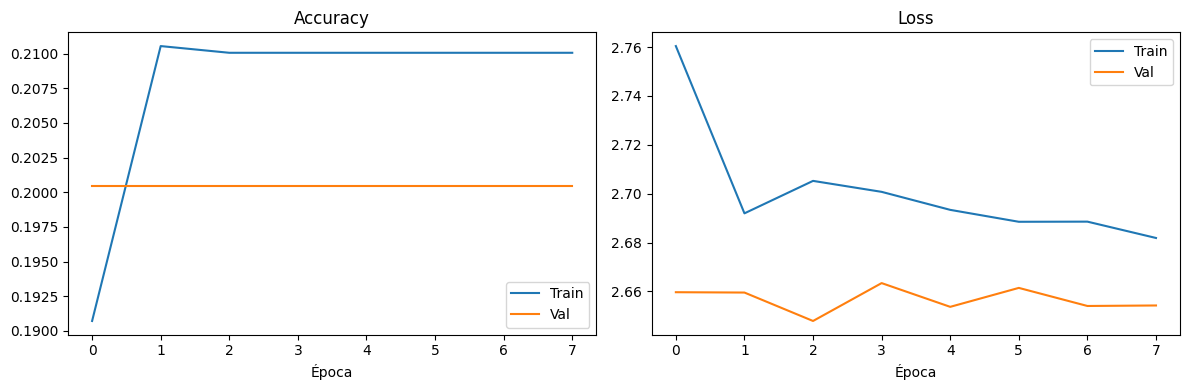

Gráfica guardada


In [34]:
import matplotlib.pyplot as plt

# Guardar modelo
model_eff.save('/kaggle/working/efficientnet_uecfood.h5')

# Curva de entrenamiento
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.xlabel('Época')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss')
plt.xlabel('Época')
plt.legend()

plt.tight_layout()
plt.savefig('/kaggle/working/efficientnet_results.png', dpi=150)
plt.show()
print('Gráfica guardada')